In [1]:
!pip install --quiet networkx matplotlib numpy

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
import threading
import time
import tracemalloc
import copy
from collections import defaultdict

In [2]:
# ── CONFIGURATION CONSTANT ──
HAZARD_PENALTY = 1.5            # multiplier for “caution” edges

G = nx.Graph()

floors = 6
x_rooms = 8
y_rooms = 8

# Updated spacings
room_spacing_x = 24
room_spacing_y = 26
floor_spacing_z = 15  # vertical spacing between floors

room_ids = {}

for z in range(floors):
    for y in range(y_rooms):
        for x in range(x_rooms):
            room_num = z * 100 + 101 + (y * x_rooms + x)
            node_id = str(room_num)

            G.add_node(node_id,
                       type="room",
                       x=x * room_spacing_x,
                       y=y * room_spacing_y,
                       z=z * floor_spacing_z,  # this is the vertical separation
                       structural_integrity=1.0,
                       gas_leak=False,
                       )

            room_ids[(x, y, z)] = node_id

# ── DESIGNATE GAS MAIN IN A ROOM ──
# (for this example, put it in Room 101 at (0,0,0))
gas_room = room_ids[(0, 1, 0)]
G.nodes[gas_room]['has_gas_main'] = True
print(f"🔍 Gas main located at room {gas_room}")


🔍 Gas main located at room 109


In [3]:
import random

PATIENT_WEIGHT_MEAN = 175   # US average adult, lbs
PATIENT_WEIGHT_SD   = 30
PATIENT_WEIGHT_MIN  = 90
PATIENT_WEIGHT_MAX  = 330

def random_patient_weight():
    w = int(random.gauss(PATIENT_WEIGHT_MEAN, PATIENT_WEIGHT_SD))
    return min(max(w, PATIENT_WEIGHT_MIN), PATIENT_WEIGHT_MAX)

robot_profiles = [
    # TractorBot: for debris, heavy patients, and clearing blocked paths
    {
        'name': 'TractorBot', 'mass': 140,
        'skills': {
            'debris_clearance': 10, 'obstruction_removal': 9, 'patient_capacity': 3,
            'weight_support': 330, 'carry_speed': 3.5,  # No penalty for any weight patient
            'slippery_navigation': 4, 'stair_climbing': 3, 'elevator_usage': 2
        },
        'traits': ['heavyweight', 'robust', 'powerful'],
        'weaknesses': ['slow', 'cannot_use_elevator']
        # NOTE: Should not be used to transport light patients unless no others are available
    },

    # Skater: light, fast, only for light/medium patients
    {
        'name': 'Skater', 'mass': 45,
        'skills': {
            'slippery_navigation': 10, 'patient_capacity': 1, 'weight_support': 120, 'carry_speed': 8.0,
            'debris_clearance': 2, 'stair_climbing': 10, 'elevator_usage': 10
        },
        'traits': ['agile', 'lightweight', 'fast'],
        'weaknesses': ['fragile', 'weak_against_debris']
        # NOTE: Can’t be assigned to heavy patients (weight > 120 lbs)
    },

    # MedPorter: medium speed, high patient capacity, ideal for moving groups
    {
        'name': 'MedPorter', 'mass': 90,
        'skills': {
            'patient_capacity': 6, 'weight_support': 210, 'carry_speed': 5.0,
            'debris_clearance': 5, 'stair_climbing': 4, 'elevator_usage': 6
        },
        'traits': ['robust', 'group_transport'],
        'weaknesses': ['large', 'cannot_climb_stairs']
    },

    # GlassGuard: fast, but only for small/light patients
    {
        'name': 'GlassGuard', 'mass': 50,
        'skills': {
            'glass_safety': 10, 'patient_capacity': 1, 'weight_support': 130, 'carry_speed': 7.5,
            'night_vision': 6, 'stair_climbing': 6
        },
        'traits': ['fast', 'glass_protect'],
        'weaknesses': ['low_weight_support']
    },

    # BlockBuster: for obstructions, moderate carry
    {
        'name': 'BlockBuster', 'mass': 110,
        'skills': {
            'obstruction_removal': 10, 'debris_clearance': 9, 'patient_capacity': 2,
            'weight_support': 210, 'carry_speed': 4.2, 'stair_climbing': 4
        },
        'traits': ['has_tools', 'mediumweight'],
        'weaknesses': ['slow_on_stairs']
    },

    # MedDrone: cannot transport, but assists in other tasks
    {
        'name': 'MedDrone', 'mass': 18,
        'skills': {
            'patient_capacity': 0, 'weight_support': 0, 'carry_speed': 0,
            'gas_detection': 8, 'night_vision': 10
        },
        'traits': ['remote_operation', 'scout'],
        'weaknesses': ['cannot_transport_patients']
    },
]

# Expand to more robots with varied skills
for i in range(7, 31):
    patient_capacity = random.choices([0, 1, 2, 3, 4], weights=[0.1, 0.5, 0.2, 0.15, 0.05])[0]
    weight_support = random.randint(80, 330)
    carry_speed = round(random.uniform(3.0, 8.0), 1) if patient_capacity else 0
    robot_profiles.append({
        'name': f'RobotType{i}',
        'mass': random.randint(30, 180),
        'skills': {
            'patient_capacity': patient_capacity,
            'weight_support': weight_support,
            'carry_speed': carry_speed,
            'debris_clearance': random.randint(1,10),
            'obstruction_removal': random.randint(1,10),
            'slippery_navigation': random.randint(1,10),
            'stair_climbing': random.randint(1,10),
            'elevator_usage': random.randint(1,10),
        },
        'traits': random.sample(['lightweight','heavyweight','fast','slow','robust','agile','insulated','scout','group_transport','powerful'], 2),
        'weaknesses': random.sample(['fragile','large','cannot_climb_stairs','slow_on_stairs','no_night_vision','low_weight_support'], 2)
    })

# --- Patient Profiles ---
def generate_patients(num_patients=20):
    patients = []
    for i in range(num_patients):
        weight = random_patient_weight()
        patients.append({'id': f'P{i+1}', 'weight': weight})
    return patients

# --- Example printout
import pprint
print("=== Example Robots ===")
pprint.pprint(robot_profiles[:5])
print("=== Example Patients ===")
pprint.pprint(generate_patients(5))


=== Example Robots ===
[{'mass': 140,
  'name': 'TractorBot',
  'skills': {'carry_speed': 3.5,
             'debris_clearance': 10,
             'elevator_usage': 2,
             'obstruction_removal': 9,
             'patient_capacity': 3,
             'slippery_navigation': 4,
             'stair_climbing': 3,
             'weight_support': 330},
  'traits': ['heavyweight', 'robust', 'powerful'],
  'weaknesses': ['slow', 'cannot_use_elevator']},
 {'mass': 45,
  'name': 'Skater',
  'skills': {'carry_speed': 8.0,
             'debris_clearance': 2,
             'elevator_usage': 10,
             'patient_capacity': 1,
             'slippery_navigation': 10,
             'stair_climbing': 10,
             'weight_support': 120},
  'traits': ['agile', 'lightweight', 'fast'],
  'weaknesses': ['fragile', 'weak_against_debris']},
 {'mass': 90,
  'name': 'MedPorter',
  'skills': {'carry_speed': 5.0,
             'debris_clearance': 5,
             'elevator_usage': 6,
             'patient_c

In [4]:
# Connect horizontal (E/W) rooms in each row
for z in range(floors):
    for y in range(y_rooms):
        for x in range(x_rooms - 1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x + 1, y, z)]
            G.add_edge(n1, n2,
                       edge_type="hallway",
                       status="open",
                       distance=room_spacing_x,
                       trust_score=1.0,
                       structural_risk=0.0,
                       hazard_level='healthy')
            if random.random() < 0.15:
                G[n1][n2]['hazard_level'] = 'caution'


# Connect vertical (N/S) outer columns only: left column (x=0), right column (x=3)
outer_cols = [0, x_rooms - 1]

for z in range(floors):
    for x in outer_cols:
        for y in range(y_rooms - 1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x, y + 1, z)]
            G.add_edge(n1, n2,
                       edge_type="hallway",
                       status="open",
                       distance=room_spacing_y,
                       trust_score=1.0,
                       structural_risk=0.0,
                       hazard_level='healthy')
            if random.random() < 0.15:
                G[n1][n2]['hazard_level'] = 'caution'



In [5]:
# ── MULTIPLE ELEVATORS AND STAIRS ──
# Place elevators and stairs in opposite corners, at least min_dist apart.

min_dist = max(x_rooms, y_rooms) // 2

# Corners to choose from
corners = [(0,0), (0,y_rooms-1), (x_rooms-1,0), (x_rooms-1,y_rooms-1)]

# Pick two corners for elevators that are far apart
elevator_stack = [corners[0], corners[3]]   # front‑left and back‑right

# Pick the other two corners for stairs
stair_stack    = [corners[1], corners[2]]   # back‑left and front‑right

# Now add elevator edges
for x, y in elevator_stack:
    for z in range(floors-1):
        n1 = room_ids[(x, y, z)]
        n2 = room_ids[(x, y, z+1)]
        G.add_edge(n1, n2,
                   edge_type="elevator",
                   status="open",
                   distance=floor_spacing_z,
                   trust_score=1.0,
                   structural_risk=0.0,
                   hazard_level='healthy')

# And stair edges
for x, y in stair_stack:
    for z in range(floors-1):
        n1 = room_ids[(x, y, z)]
        n2 = room_ids[(x, y, z+1)]
        G.add_edge(n1, n2,
                   edge_type="stair",
                   status="open",
                   distance=floor_spacing_z,
                   trust_score=1.0,
                   structural_risk=0.0,
                   hazard_level='healthy')


In [6]:
# Check if the graph is fully connected
if nx.is_connected(G):
    print("✅ The hospital graph is fully connected.")
else:
    print("❌ The graph is NOT connected. There may be isolated rooms or missing edges.")


✅ The hospital graph is fully connected.


In [7]:
# 1. Set room types (assign these FIRST)
room_types = ["ward", "ICU", "OR", "storage", "lobby"]
for node, data in G.nodes(data=True):
    if data.get("type") == "room":
        data.update({
            "room_type": random.choice(room_types),
            "structural_integrity": 1.0,
            "temperature": 22.0,
            "gas_leak": False,
        })

# 2. Assign realistic occupants (before urgencies/expirations!)
for node, data in G.nodes(data=True):
    if data.get("type") == "room":
        rt = data.get("room_type", "ward")
        if rt == "ICU":
            occ_prob = [0.6, 0.3, 0.1]  # 0, 1, or 2 patients in ICU
            occs = np.random.choice([0,1,2], p=occ_prob)
        elif rt == "ward":
            occ_prob = [0.2, 0.3, 0.3, 0.2]  # 0–3 patients
            occs = np.random.choice([0,1,2,3], p=occ_prob)
        else:
            occs = np.random.choice([0,1], p=[0.7,0.3])  # rarely occupied
        data["occupants"] = int(occs)

# 3. Assign patient urgencies (must come after occupants)
for node, data in G.nodes(data=True):
    if data.get("type") == "room" and data["occupants"] > 0:
        rt = data.get("room_type", "ward")
        if rt == "ICU":
            room_mean, room_sd = 80, 10
        elif rt == "ward":
            room_mean, room_sd = 50, 20
        else:  # OR, storage, lobby
            room_mean, room_sd = 30, 15
        urgencies = np.clip(np.random.normal(room_mean, room_sd, data["occupants"]), 1, 100).astype(int)
        data["patient_urgencies"] = list(urgencies)
    else:
        data["patient_urgencies"] = []

# 4. Assign patient expiration times (after occupants)
for node, data in G.nodes(data=True):
    if data.get("type") == "room" and data["occupants"] > 0:
        expirations = np.random.randint(1200, 3600, size=data["occupants"])
        data["patient_expirations"] = list(expirations)
    else:
        data["patient_expirations"] = []

# 5. Build the patient list (last)
PATIENT_WEIGHT_MEAN = 175   # US avg adult, lbs
PATIENT_WEIGHT_SD   = 30
PATIENT_WEIGHT_MIN  = 90
PATIENT_WEIGHT_MAX  = 330

def random_patient_weight():
    w = int(random.gauss(PATIENT_WEIGHT_MEAN, PATIENT_WEIGHT_SD))
    return min(max(w, PATIENT_WEIGHT_MIN), PATIENT_WEIGHT_MAX)

# 5. Build the patient list (last)
patient_list = []
for node, data in G.nodes(data=True):
    if data.get("type") == "room" and data["occupants"] > 0:
        for i in range(data["occupants"]):
            patient_list.append({
                "room": node,
                "urgency": data["patient_urgencies"][i],
                "expiration": data["patient_expirations"][i],
                "weight": random_patient_weight(),
                "assigned": False,
                "rescued": False,
                "failed": False
            })
print(f"Total patients created: {len(patient_list)}")




Total patients created: 239


In [8]:
# ── MARK ROOMS WITH ALL-EDGE BLOCKAGES ──
blocked_rooms = {
    n
    for n,d in G.nodes(data=True)
    if d.get("type")=="room"
    and all(
        G[n][nbr]["hazard_level"] == "blocked"
        for nbr in G.neighbors(n)
    )
}


# ── EXPLORER THAT RETURNS THE FULL SEQUENCE ──
def explore_with_sequence(G, start):
    visited = {start}
    stack   = [start]
    sequence = []

    while stack:
        current = stack[-1]
        sequence.append(current)

        # 1) sniff current room
        if G.nodes[current].get('gas_leak', False):
            return sequence, stack

        # 2) sense hazards (for record only)
        for nbr in G.neighbors(current):
            _ = G[current][nbr].get('hazard_level', 'healthy')

        # 3) pick a random, unvisited, unblocked neighbor
        nbrs = [
            nbr for nbr in G.neighbors(current)
            if nbr not in visited
            and G[current][nbr].get('hazard_level','healthy')!='blocked'
            and nbr not in blocked_rooms
        ]

        random.shuffle(nbrs)

        if nbrs:
            nxt = nbrs[0]
            visited.add(nxt)
            stack.append(nxt)
        else:
            stack.pop()

    return sequence, None


In [9]:
# 🚪 Add Exit Node between Room 102 and 103 (on floor 0)
room_102 = room_ids[(1, 0, 0)]  # This gives you "102"
room_103 = room_ids[(2, 0, 0)]  # This gives you "103"

# Get positions of each room
x1, y1, z1 = G.nodes[room_102]["x"], G.nodes[room_102]["y"], G.nodes[room_102]["z"]
x2, y2, z2 = G.nodes[room_103]["x"], G.nodes[room_103]["y"], G.nodes[room_103]["z"]

# Midpoint position
exit_x = (x1 + x2) / 2
exit_y = (y1 + y2) / 2
exit_z = z1  # same floor

# Create EXIT node
exit_node_id = "EXIT"
G.add_node(exit_node_id,
           type="exit",
           x=exit_x,
           y=exit_y,
           z=exit_z)

# Connect to both rooms
G.add_edge(room_102, exit_node_id,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)

G.add_edge(room_103, exit_node_id,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)

print(f"✅ Exit node placed between {room_102} and {room_103}")

print("Is EXIT in G.nodes?", exit_node_id in G.nodes())

# 🚪 Add a second EXIT node on opposite side (e.g., between Room 104 and 105 on floor 0)
room_104 = room_ids[(0, 2, 0)]  # Pick another pair on opposite side
room_105 = room_ids[(3, 2, 0)]
exit2_x = (G.nodes[room_104]['x'] + G.nodes[room_105]['x']) / 2
exit2_y = (G.nodes[room_104]['y'] + G.nodes[room_105]['y']) / 2
exit2_z = G.nodes[room_104]['z']

exit_node_id2 = "EXIT2"
G.add_node(exit_node_id2,
           type="exit",
           x=exit2_x,
           y=exit2_y,
           z=exit2_z)

G.add_edge(room_104, exit_node_id2,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)
G.add_edge(room_105, exit_node_id2,
           edge_type="exit",
           status="open",
           distance=10,
           trust_score=1.0,
           structural_risk=0.0)

print(f"✅ Second exit node placed between {room_104} and {room_105}")





✅ Exit node placed between 102 and 103
Is EXIT in G.nodes? True
✅ Second exit node placed between 117 and 120


In [10]:
# ── TWO EXIT NODES ON OPPOSITE SIDES OF FLOOR 0 ──

exits = []
# Exit A between rooms (1,0,0) & (2,0,0)  — west side
for coords in [((1,0,0),(2,0,0)), ((x_rooms-3, y_rooms-1, 0),(x_rooms-2, y_rooms-1, 0))]:
    (x1,y1,z1), (x2,y2,z2) = coords
    room_a = room_ids[(x1,y1,z1)]
    room_b = room_ids[(x2,y2,z2)]
    x_mid = (G.nodes[room_a]['x'] + G.nodes[room_b]['x'])/2
    y_mid = (G.nodes[room_a]['y'] + G.nodes[room_b]['y'])/2
    exit_id = f"EXIT_{x1}{y1}"
    G.add_node(exit_id,
               type="exit",
               x=x_mid, y=y_mid, z=z1)
    G.add_edge(room_a, exit_id,
               edge_type="exit",
               status="open",
               distance=10,
               trust_score=1.0,
               structural_risk=0.0)
    G.add_edge(room_b, exit_id,
               edge_type="exit",
               status="open",
               distance=10,
               trust_score=1.0,
               structural_risk=0.0)
    exits.append(exit_id)

print(f"✅ Exit nodes placed: {exits}")

# ── PICK A “DEFAULT” EXIT NODE FOR ROBOTS TO START FROM ──
# (you can change exits[0] → exits[1] if you prefer the other exit)
exit_node_id = exits[0]
print(f"🔑 Using exit_node_id = {exit_node_id} for all robot dispatch")


✅ Exit nodes placed: ['EXIT_10', 'EXIT_57']
🔑 Using exit_node_id = EXIT_10 for all robot dispatch


In [11]:

for (x, y, z), room_id in room_ids.items():
    if x == x_rooms - 1:  # east-most column
        G.nodes[room_id]["structural_integrity"] = round(random.uniform(0.1, 0.4), 2)
        #G.nodes[room_id]["gas_leak"] = random.random() < 0.5
        G.nodes[room_id]["lighting"] = round(random.uniform(0.0, 0.3), 2)


In [12]:
# ── MAJOR AND MINOR STRUCTURAL DAMAGE FROM “EARTHQUAKE” ──
# We'll create a Gaussian-like spread of damage centered on the east wing.

import math

epicenter_x = x_rooms - 1
sigma       = 1.5   # controls spread: 1.5 floors over = pretty localized

for (x, y, z), room_id in room_ids.items():
    # compute horizontal distance from epicenter (in columns)
    dist = abs(x - epicenter_x)
    # damage probability falls off with a Gaussian
    p_damage = math.exp(-0.5 * (dist/sigma)**2)
    if random.random() < p_damage:
        # major damage
        G.nodes[room_id]['structural_integrity'] = round(random.uniform(0.1, 0.4), 2)
    else:
        # minor or no damage
        if random.random() < 0.2:
            G.nodes[room_id]['structural_integrity'] = round(random.uniform(0.4, 0.7), 2)

# Now propagate that into corridor (edge) blockages/hazards:
for u, v, attr in G.edges(data=True):
    # if either end is badly damaged, higher chance corridor is blocked
    si_u = G.nodes[u].get('structural_integrity', 1.0)
    si_v = G.nodes[v].get('structural_integrity', 1.0)
    p_block = max(0, (1 - si_u)) * max(0, (1 - si_v))
    if random.random() < p_block:
        attr['status'] = 'blocked'
        attr['hazard_level'] = 'blocked'
    elif random.random() < 0.1:
        attr['hazard_level'] = 'caution'


In [13]:
# ── ENSURE EVERY EDGE HAS hazard_level ──
for u, v, attr in G.edges(data=True):
    if attr.get('status') == 'blocked':
        G[u][v]['hazard_level'] = 'blocked'
    elif 'hazard_level' not in attr:
        G[u][v]['hazard_level'] = 'healthy'


In [14]:
def assign_minor_hazards(G, x_range=None, z_range=None):
    """
    Randomly add minor hazard attributes to rooms.
    - x_range: tuple of x positions to target (e.g. (2, 4)), or None for all
    - z_range: tuple of z (floor) values to target (e.g. (0, 2)), or None for all
    """
    hazard_types = ["glass_shards", "obstruction", "slippery", "ceiling_damage"]
    affected = 0

    for n, d in G.nodes(data=True):
        if d.get("type") != "room":
            continue

        x = int(d["x"] // room_spacing_x)
        z = d["z"]

        if x_range and not (x_range[0] <= x <= x_range[1]):
            continue
        if z_range and not (z_range[0] <= z <= z_range[1]):
            continue

        for hazard in hazard_types:
            d[hazard] = random.random() < 0.1

        if any(d.get(h) for h in hazard_types):
            affected += 1

    print(f"✔️ Minor hazards assigned to {affected} rooms.")




In [15]:
assign_minor_hazards(G)



✔️ Minor hazards assigned to 129 rooms.


In [16]:
# Check how many rooms actually got hazards (Debug)
hazard_types = ["glass_shards", "obstruction", "slippery", "ceiling_damage"]
hazard_count = 0

for n, d in G.nodes(data=True):
    if d.get("type") != "room":
        continue
    if any(d.get(h, False) for h in hazard_types):
        print(f"⚠️ Room {n} has hazards: {[h for h in hazard_types if d.get(h, False)]}")
        hazard_count += 1

if hazard_count == 0:
    print("❌ No hazards assigned. Something is wrong.")
else:
    print(f"✅ {hazard_count} rooms have at least one hazard.")


⚠️ Room 102 has hazards: ['glass_shards', 'obstruction']
⚠️ Room 104 has hazards: ['obstruction']
⚠️ Room 112 has hazards: ['obstruction']
⚠️ Room 126 has hazards: ['slippery']
⚠️ Room 128 has hazards: ['glass_shards']
⚠️ Room 132 has hazards: ['slippery']
⚠️ Room 133 has hazards: ['obstruction']
⚠️ Room 134 has hazards: ['ceiling_damage']
⚠️ Room 135 has hazards: ['glass_shards']
⚠️ Room 137 has hazards: ['ceiling_damage']
⚠️ Room 138 has hazards: ['obstruction']
⚠️ Room 143 has hazards: ['glass_shards', 'ceiling_damage']
⚠️ Room 146 has hazards: ['ceiling_damage']
⚠️ Room 151 has hazards: ['ceiling_damage']
⚠️ Room 153 has hazards: ['slippery', 'ceiling_damage']
⚠️ Room 154 has hazards: ['slippery']
⚠️ Room 156 has hazards: ['glass_shards']
⚠️ Room 157 has hazards: ['glass_shards']
⚠️ Room 161 has hazards: ['slippery']
⚠️ Room 202 has hazards: ['glass_shards']
⚠️ Room 205 has hazards: ['ceiling_damage']
⚠️ Room 206 has hazards: ['ceiling_damage']
⚠️ Room 209 has hazards: ['ceiling_da

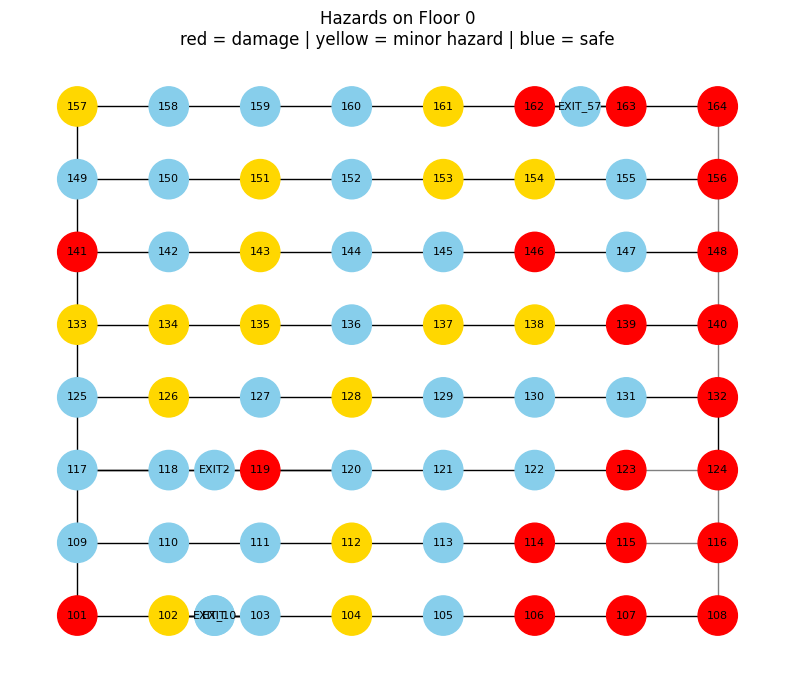

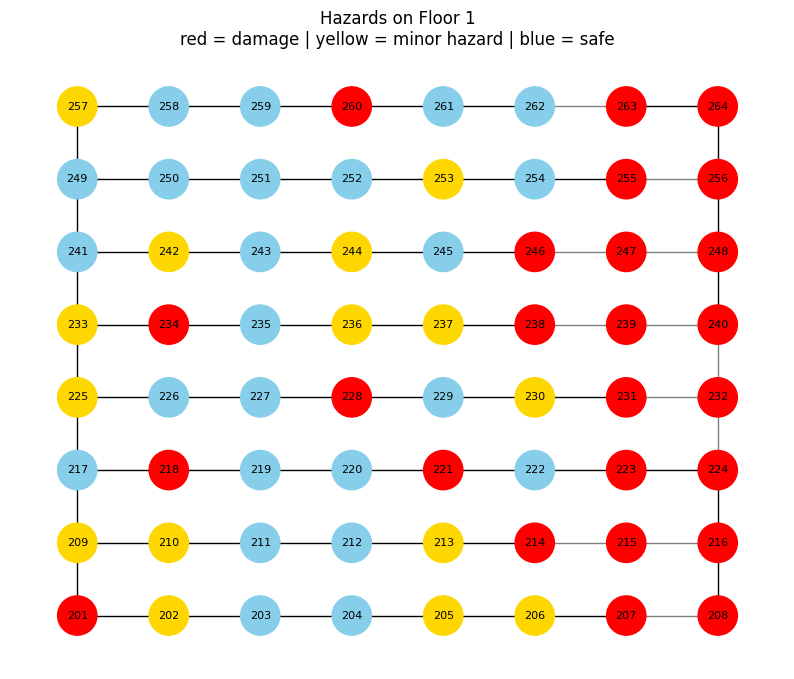

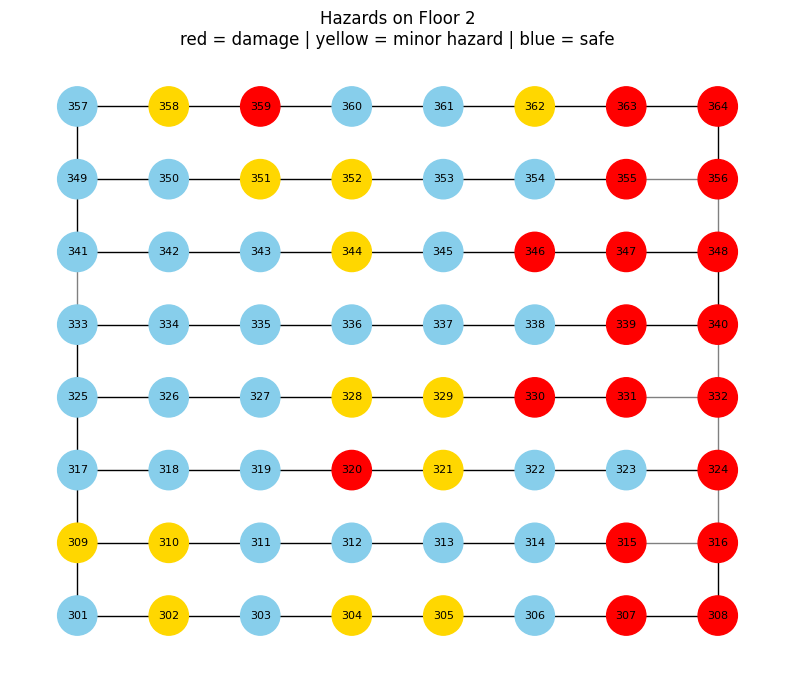

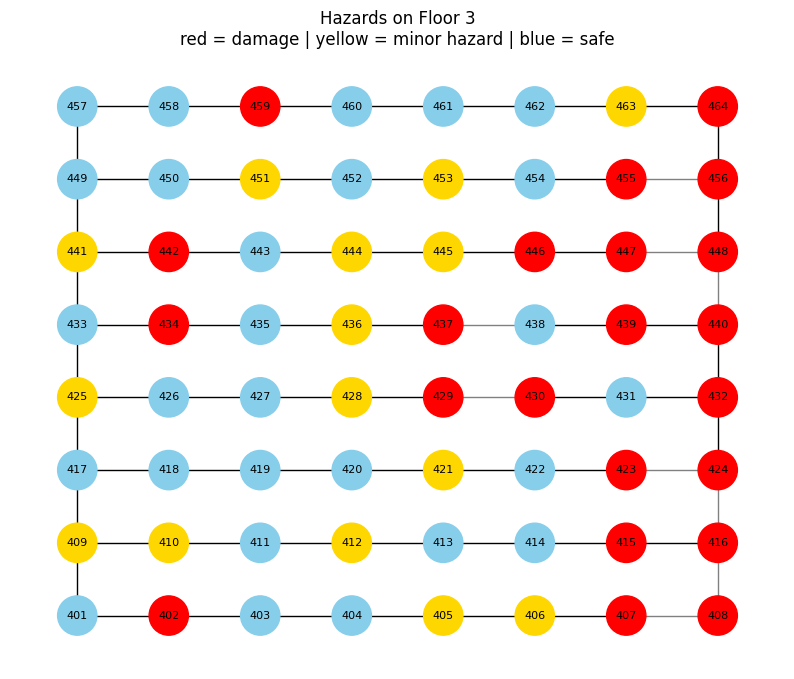

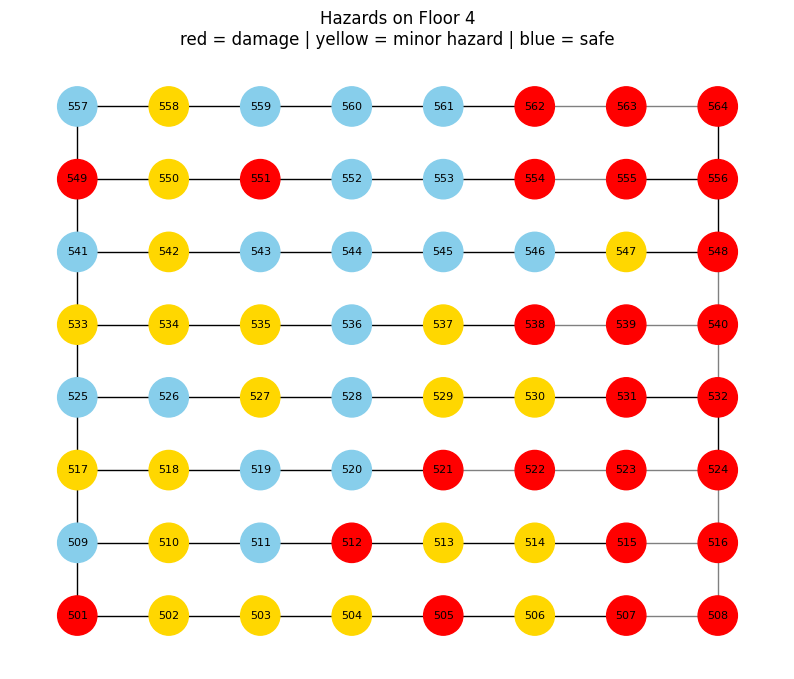

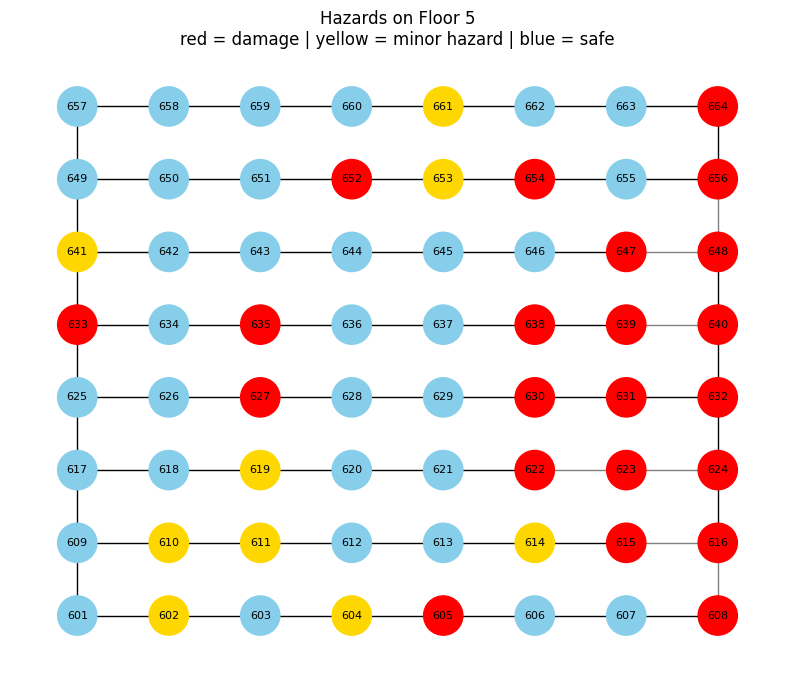

In [17]:
def visualize_hazards_on_floor(G, z_level):
    plt.figure(figsize=(10, 8))

    # Get nodes on this floor
    floor_nodes = [n for n, d in G.nodes(data=True) if d["z"] == z_level * floor_spacing_z]
    pos = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in floor_nodes}

    # Determine node color
    node_colors = []
    for n in floor_nodes:
        d = G.nodes[n]
        integrity = d.get("structural_integrity", 1.0)
        has_minor_hazard = any([
            d.get("glass_shards", False),
            d.get("obstruction", False),
            d.get("slippery", False),
            d.get("ceiling_damage", False)
        ])

        if integrity < 0.5:
            node_colors.append("red")      # major structural damage
        elif has_minor_hazard:
            node_colors.append("gold")     # minor hazard only
        else:
            node_colors.append("skyblue")  # safe room



    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=floor_nodes, node_color=node_colors, node_size=800)
    nx.draw_networkx_labels(G, pos, labels={n: n for n in floor_nodes}, font_size=8)

    # Draw edges
    floor_edges = [(u, v) for u, v in G.edges() if u in floor_nodes and v in floor_nodes]
    edge_colors = ["gray" if G[u][v].get("status") == "blocked" else "black" for u, v in floor_edges]
    nx.draw_networkx_edges(G, pos, edgelist=floor_edges, edge_color=edge_colors)

    plt.title(f"Hazards on Floor {z_level}\nred = damage | yellow = minor hazard | blue = safe")
    plt.axis("off")
    plt.show()

for z in range(floors):
    visualize_hazards_on_floor(G, z)


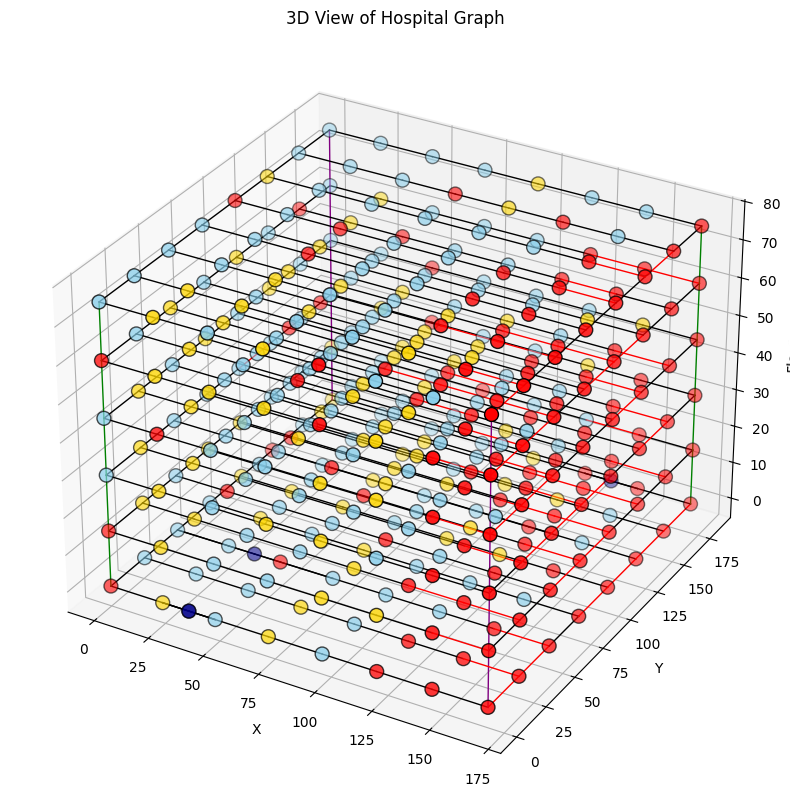

In [18]:
from mpl_toolkits.mplot3d import Axes3D

def visualize_hospital_3D(G):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Position of each node
    node_pos = {}
    xs, ys, zs, colors = [], [], [], []

    for n, d in G.nodes(data=True):
        if d.get("type") not in ["room", "exit"]:
            continue
        x, y, z = d["x"], d["y"], d["z"]
        node_pos[n] = (x, y, z)
        xs.append(x)
        ys.append(y)
        zs.append(z)

        # Color nodes
        if d.get("type") == "exit":
            colors.append("darkblue")  # Exit node color
        else:
            integrity = d.get("structural_integrity", 1.0)
            has_minor_hazard = any([
                d.get("glass_shards", False),
                d.get("obstruction", False),
                d.get("slippery", False),
                d.get("ceiling_damage", False)
            ])

            if integrity < 0.5:
                colors.append("red")
            elif has_minor_hazard:
                colors.append("gold")
            else:
                colors.append("skyblue")

    # Draw nodes
    ax.scatter(xs, ys, zs, c=colors, s=100, edgecolors='k')

    # Draw edges
    for u, v, attr in G.edges(data=True):
        if u not in node_pos or v not in node_pos:
            continue
        x_vals = [node_pos[u][0], node_pos[v][0]]
        y_vals = [node_pos[u][1], node_pos[v][1]]
        z_vals = [node_pos[u][2], node_pos[v][2]]

        # Color edges based on priority
        if attr.get("edge_type") == "stair":
            color = "purple"
        elif attr.get("edge_type") == "elevator":
            color = "green"
        elif attr.get("hazard") == "debris":
            color = "yellow"
        elif attr.get("status") == "blocked":
            color = "red"
        else:
            color = "black"


        ax.plot(x_vals, y_vals, z_vals, color=color, linewidth=1)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Floor")
    ax.set_title("3D View of Hospital Graph")
    plt.show()

# Run it
visualize_hospital_3D(G)


In [19]:
# ── MARK ROOMS WITH ALL-EDGE BLOCKAGES ──
blocked_rooms = {
    n
    for n,d in G.nodes(data=True)
    if d.get("type")=="room"
    and all(
        G[n][nbr]["hazard_level"] == "blocked"
        for nbr in G.neighbors(n)
    )
}
print(f"🚧 Blocked rooms (no open corridors): {sorted(blocked_rooms)}")


🚧 Blocked rooms (no open corridors): ['116', '215', '232', '239', '247', '332', '408', '516', '522', '523', '539', '540', '563', '623']


In [20]:
# ── LOCAL KNOWLEDGE SHARING SETUP ──

import networkx as nx
import threading

# 1) Shared map: what rooms have been seen and where patients are
shared_map = {
    'discovered_nodes': set(),   # rooms we've “seen” so far
    'patients': {}               # mapping room_id → occupancy
}
map_lock = threading.Lock()

# 2) Local navigator: shortest path on the subgraph of discovered nodes
# ── LOCAL ROUTER WITH BLOCKED‐EDGE FILTERING ──




In [21]:
# ── SEED A GAS LEAK ──
# (Change the tuple if you want a different room)
leak_room = room_ids[(0, 0, 0)]
G.nodes[leak_room]['gas_leak'] = True
print(f"🔍 Gas leak seeded in room {leak_room}")


🔍 Gas leak seeded in room 101


In [22]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


import time
import tracemalloc

def benchmark_algorithm(algorithm_fn, *args, **kwargs):
    """
    Run the given algorithm and measure runtime and peak memory.
    Returns: result, runtime (sec), peak_mem (MB)
    """
    tracemalloc.start()
    start_time = time.perf_counter()
    result = algorithm_fn(*args, **kwargs)
    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    runtime = end_time - start_time
    peak_mb = peak / 1e6
    return result, runtime, peak_mb


# --- Benchmark All-Pairs Dijkstra ---

room_nodes = [n for n, d in G.nodes(data=True) if d['type'] == 'room']

def all_pairs_dijkstra(G, nodes):
    # Returns shortest paths between all pairs of rooms
    return dict(nx.all_pairs_dijkstra_path_length(G, weight='distance'))

print("⏱️ Benchmarking all-pairs Dijkstra...")
dijkstra_result, dijkstra_time, dijkstra_mem = benchmark_algorithm(
    all_pairs_dijkstra, G, room_nodes
)
print(f"Dijkstra All-Pairs: {dijkstra_time:.2f} sec, Peak mem: {dijkstra_mem:.1f} MB")

def visualize_path_3D(G, path):
    """
    Draw the full hospital graph in light gray/blue,
    then overlay the agent's path in bold red.
    """
    # Build 3D positions for rooms and exit
    node_pos = {
        n: (d['x'], d['y'], d['z'])
        for n, d in G.nodes(data=True)
        if d.get("type") in ("room", "exit")
    }

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # 1) Draw all edges in light gray
    for u, v in G.edges():
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='lightgray', linewidth=1)

    # 2) Draw all nodes (rooms in skyblue, exit in darkblue)
    for n, (x, y, z) in node_pos.items():
        color = 'darkblue' if G.nodes[n]['type'] == 'exit' else 'skyblue'
        ax.scatter(x, y, z, c=color, s=50, edgecolors='k', alpha=0.6)

    # 3) Overlay the path edges in red
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='red', linewidth=3)

    # 4) Highlight the path nodes in red
    for n in path:
        if n in node_pos:
            x, y, z = node_pos[n]
            ax.scatter(x, y, z, c='red', s=100, edgecolors='k')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (floor)")
    ax.set_title("3D Hospital Graph with Agent Path (red)")
    plt.show()


⏱️ Benchmarking all-pairs Dijkstra...
Dijkstra All-Pairs: 4.14 sec, Peak mem: 7.3 MB


In [23]:
import random

# ── EXPLORER THAT RETURNS THE FULL SEQUENCE ──
def explore_with_sequence(G, start):
    visited = {start}
    stack   = [start]
    sequence = []

    while stack:
        current = stack[-1]
        sequence.append(current)

        # 1) sniff current room
        if G.nodes[current].get('gas_leak', False):
            return sequence, stack

        # 2) sense hazards (for record only)
        for nbr in G.neighbors(current):
            _ = G[current][nbr].get('hazard_level', 'healthy')

        # 3) pick a random, unvisited, unblocked neighbor
        nbrs = [
            nbr for nbr in G.neighbors(current)
            if nbr not in visited
            and G[current][nbr].get('hazard_level','healthy')!='blocked'
            and nbr not in blocked_rooms            # <- skip fully blocked rooms
        ]

        random.shuffle(nbrs)

        if nbrs:
            nxt = nbrs[0]
            visited.add(nxt)
            stack.append(nxt)
        else:
            stack.pop()

    return sequence, None

# ── 3D VISUALIZER FOR THE EXPLORATION SEQUENCE ──
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

def visualize_exploration_3D(G, sequence):
    node_pos = {
        n: (d['x'], d['y'], d['z'])
        for n, d in G.nodes(data=True)
        if d.get("type") in ("room","exit")
    }

    fig = plt.figure(figsize=(12,10))
    ax  = fig.add_subplot(111, projection='3d')

    # faint hospital graph
    for u, v in G.edges():
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='lightgray', linewidth=1)

    # rooms & exit
    for n,(x,y,z) in node_pos.items():
        color = 'darkblue' if G.nodes[n]['type']=='exit' else 'skyblue'
        ax.scatter(x,y,z, c=color, s=50, edgecolors='k', alpha=0.6)

    # exploration in orange
    for i in range(len(sequence)-1):
        u, v = sequence[i], sequence[i+1]
        if u in node_pos and v in node_pos:
            xs, ys, zs = zip(node_pos[u], node_pos[v])
            ax.plot(xs, ys, zs, color='orange', linewidth=2)

    # step‐number labels
    for idx, n in enumerate(sequence):
        if n in node_pos:
            x,y,z = node_pos[n]
            ax.text(x, y, z, str(idx), color='red', fontsize=8, zorder=10)
            ax.scatter(x, y, z, c='red', s=80, edgecolors='k')

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (floor)")
    ax.set_title("3D Exploration Sequence (orange) with Step Numbers")
    plt.show()


In [ ]:
# ── RUN & VISUALIZE FULL EXPLORATION ──
start_room = room_ids[(2, 0, 2)]  # "303"
sequence, path = explore_with_sequence(G, start_room)

print("🔎 Full exploration sequence:", " → ".join(sequence))
if path:
    print("🛣️ Leak found! Final path:", " → ".join(path))
else:
    print("❌ Leak not found from", start_room)

visualize_exploration_3D(G, sequence)


🔎 Full exploration sequence: 303 → 304 → 305 → 306 → 307 → 308 → 316 → 308 → 307 → 306 → 305 → 304 → 303 → 302 → 301 → 201 → 209 → 210 → 211 → 212 → 213 → 214 → 213 → 212 → 211 → 210 → 209 → 217 → 225 → 233 → 241 → 249 → 257 → 357 → 457 → 449 → 450 → 451 → 452 → 453 → 454 → 455 → 454 → 453 → 452 → 451 → 450 → 449 → 441 → 433 → 425 → 417 → 409 → 401 → 501 → 509 → 517 → 525 → 526 → 527 → 528 → 529 → 530 → 531 → 532 → 524 → 532 → 531 → 530 → 529 → 528 → 527 → 526 → 525 → 533 → 534 → 535 → 536 → 537 → 538 → 537 → 536 → 535 → 534 → 533 → 541 → 542 → 543 → 544 → 545 → 546 → 547 → 548 → 556 → 564 → 556 → 555 → 556 → 548 → 547 → 546 → 545 → 544 → 543 → 542 → 541 → 549 → 550 → 551 → 552 → 553 → 554 → 553 → 552 → 551 → 550 → 549 → 557 → 558 → 559 → 560 → 561 → 562 → 561 → 560 → 559 → 558 → 557 → 657 → 658 → 659 → 660 → 661 → 662 → 663 → 664 → 656 → 655 → 654 → 653 → 652 → 651 → 650 → 649 → 641 → 633 → 634 → 635 → 636 → 637 → 638 → 639 → 638 → 637 → 636 → 635 → 634 → 633 → 625 → 626 → 627 → 628 →

In [ ]:
#trying second interesting scenarion where we check for patients
def explore_for_patients(G, start):
    """
    DFS + backtracking sensor bot that records any room with occupants>0.
    Returns the exploration sequence and a dict mapping room_id→occupants.
    """
    visited = {start}
    stack   = [start]
    sequence = []
    found    = {}

    while stack:
        current = stack[-1]
        sequence.append(current)

        # record occupants if any
        occ = G.nodes[current].get('occupants', 0)
        if occ > 0:
            found[current] = occ

        # sense hazards (but don’t use for sensor)
        for nbr in G.neighbors(current):
            _ = G[current][nbr].get('hazard_level','healthy')

        # pick next unvisited, unblocked neighbor
        nbrs = [
            nbr for nbr in G.neighbors(current)
            if nbr not in visited
            and G[current][nbr].get('hazard_level','healthy')!='blocked'
            and nbr not in blocked_rooms            # <- skip fully blocked rooms
        ]

        nbrs.sort(key=lambda n: random.random())  # shuffle
        if nbrs:
            nxt = nbrs[0]
            visited.add(nxt)
            stack.append(nxt)
        else:
            stack.pop()

    return sequence, found


In [ ]:
def navigate_and_return(G, start, target, speed=0.8):
    """
    Greedy, local‐knowledge evacuation bot:
      1) navigate from `start` to `target`,
      2) then back to `start`.
    Returns two lists: path_out, path_back.
    """
    def navigate(G, start, goal):
        visited = {start}
        path = [start]
        while path[-1] != goal:
            cur = path[-1]
            nbrs = []
            for nbr in G.neighbors(cur):
                lvl = G[cur][nbr].get('hazard_level','healthy')
                # skip blocked edges, visited rooms, or fully-blocked rooms
                if lvl=='blocked' or nbr in visited or nbr in blocked_rooms:
                    continue

                # heuristic = euclid to goal + travel penalty
                x1,y1 = G.nodes[nbr]['x'], G.nodes[nbr]['y']
                x2,y2 = G.nodes[goal]['x'],G.nodes[goal]['y']
                dist_est = ((x1-x2)**2 + (y1-y2)**2)**0.5
                score = dist_est + traversal_time(cur, nbr, speed)
                nbrs.append((score, nbr))

            if not nbrs:
                path.pop()
                if not path:
                    return None
                continue

            nxt = min(nbrs, key=lambda x: x[0])[1]
            visited.add(nxt)
            path.append(nxt)
        return path

    path_out  = navigate(G, start, target)
    path_back = navigate(G, target, start) if path_out else None
    return path_out, path_back


In [ ]:
# ── SUM UP REAL TRAVERSAL TIMES AT 4 FT/S ──
def path_travel_time(G, path, speed=4.0):
    total = 0.0
    for u, v in zip(path, path[1:]):
        total += traversal_time(u, v, speed)
    return total

# ── LOCAL‐KNOWLEDGE SENSOR+ROBOT DRIVER ──

import threading

# ─── RESET shared_map BEFORE EACH EXPERIMENT ───
shared_map = {
    'discovered_nodes': set(),
    'patients': {}
}
map_lock   = threading.Lock()

rescue_log     = []
coverage_rooms = set()
lock           = threading.Lock()

sensor_starts = [
    room_ids[(0, 0, 0)],  # Room 101
    room_ids[(1, 1, 1)],  # Room 206
    room_ids[(2, 1, 2)]   # Room 307
]
print("🔧 Active sensors:", sensor_starts)

# ── LOCAL ROUTER WITH DEBUG ─




In [ ]:
# ── LOCAL VS GLOBAL COMPARISON SETUP ──
import threading, time, math

# snapshot initial patient counts
initial_room_occ = {
    n: d['occupants']
    for n, d in G.nodes(data=True)
    if d.get('type') == 'room' and d['occupants'] > 0
}

# ── SANITY CHECK: list patients per room & total ──
print("🔍 Sanity check: initial patient distribution")
total_patients = 0
for room, occ in sorted(initial_room_occ.items()):
    print(f"Room {room}: {occ} patient{'s' if occ>1 else ''}")
    total_patients += occ
print(f"🏥 Total patients across all rooms: {total_patients}")
print("────────────────────────────────────────────")


# shared state for local threaded dispatch
map_lock            = threading.Lock()
cleared_rooms       = set()
rooms_with_patients = set(initial_room_occ)
local_rescue_log    = []
coverage_rooms      = set()

# ── HELPERS ──
def traversal_time(u, v, speed=4.0):
    e = G[u][v]
    if e['hazard_level']=='blocked':
        return float('inf')
    penalty = HAZARD_PENALTY if e['hazard_level']=='caution' else 1.0
    return (e['distance']/speed) * penalty


def navigate_local(start, goal, speed=4.0):
    """
    Greedy local navigator: falls back to a true shortest-path
    on the subgraph without blocked edges.
    """
    # Build a subgraph excluding blocked corridors
    H = G.copy()
    for u, v, attr in list(H.edges(data=True)):
        if attr.get('hazard_level') == 'blocked':
            H.remove_edge(u, v)

    try:
        # weight is pure distance / speed
        return nx.shortest_path(
            H, start, goal,
            weight=lambda u, v, d: d['distance'] / speed
        )
    except nx.NetworkXNoPath:
        return None


def choose_best_target(current_pos, speed=4.0):
    best, best_cost = None, float('inf')
    for r in rooms_with_patients - cleared_rooms:
        p = navigate_local(current_pos, r, speed)
        if not p:
            continue
        c = sum(traversal_time(u,v,speed) for u,v in zip(p,p[1:]))
        if c < best_cost:
            best_cost, best = c, r
    return best

# ── SUM UP REAL TRAVERSAL TIMES AT 4 FT/S ──
def path_travel_time(G, path, speed=4.0):
    total = 0.0
    for u, v in zip(path, path[1:]):
        total += traversal_time(u, v, speed)
    return total

# ── LOCAL‐KNOWLEDGE SENSOR+ROBOT DRIVER (deduped) ──
import threading

rescue_log     = []
coverage_rooms = set()
lock           = threading.Lock()

sensor_starts = [
    room_ids[(0, 0, 0)],  # Room 101
    room_ids[(1, 1, 1)],  # Room 206
    room_ids[(2, 1, 2)]   # Room 307
]
print("🔧 Active sensors:", sensor_starts)

def sensor_worker(start):
    # 1) Explore & collect local findings
    seq, found = explore_for_patients(G, start)

    # 2) Publish those findings to shared_map
    with map_lock:
        shared_map['discovered_nodes'].update(seq)
        for room_id, occ in found.items():
            if room_id not in shared_map['patients']:
                shared_map['patients'][room_id] = occ

    # 3) Log header & coverage
    log = [
        f"🔎 Sensor @ {start} explored: {' → '.join(seq)}",
        f"👥 Shared patient map now: {shared_map['patients']}"
    ]
    with lock:
        coverage_rooms.update(n for n in seq if G.nodes[n]['type']=='room')

    # 4) Dispatch robots—but only for rooms still in shared_map
    for room_id in list(found):
        with map_lock:
            occ = shared_map['patients'].pop(room_id, 0)
        if occ == 0:
            log.append(f"⚠️ Skipping {room_id}, already cleared")
            continue

        path = navigate_local(exit_node_id, room_id, speed=4.0)
        if path:
            t_out   = path_travel_time(G, path,  speed=4.0)
            t_back  = path_travel_time(G, list(reversed(path)), speed=4.0)
            t_total = t_out + t_back

            # zero out the room so no other sensor thinks there are still patients
            G.nodes[room_id]['occupants'] = 0

            rescue_log.append({
                'sensor': start, 'room': room_id,
                'patients': occ, 'time': t_total
            })
            log.append(
                f"🚑 Rescued {occ} from {room_id} "
                f"(out {t_out:.2f}s + back {t_back:.2f}s = {t_total:.2f}s)"
            )
        else:
            rescue_log.append({
                'sensor': start, 'room': room_id,
                'patients': occ, 'time': float('inf')
            })
            log.append(f"❌ Rescue failed for {room_id}")

    # 5) Flush this sensor’s log
    with lock:
        print("\n".join(log), "\n")

# Launch sensors in parallel
threads = []
for s in sensor_starts:
    t = threading.Thread(target=sensor_worker, args=(s,))
    threads.append(t)
    t.start()
for t in threads:
    t.join()

# Summarize deduped metrics
times   = [e['time'] for e in rescue_log if e['time']<float('inf')]
rescued = sum(e['patients'] for e in rescue_log if e['time']<float('inf'))

first_t = min(times) if times else float('nan')
max_t   = max(times) if times else float('nan')
total   = sum(1 for n,d in G.nodes(data=True) if d.get('type')=='room')
covered = len(coverage_rooms)
pct     = covered/total*100

print("📊 DEDUPED LOCAL Metrics:")
print(f"- Patients rescued      : {rescued}")
print(f"- Time to first rescue  : {first_t:.2f}s")
print(f"- Slowest single rescue : {max_t:.2f}s")
print(f"- Area coverage         : {covered}/{total} rooms ({pct:.1f}%)")


# ── GLOBAL‐OPTIMAL BASELINE PLANNER (excluding blocked rooms) ──

# ── RESTORE occupants for the global run ──
for node_id, occ in initial_room_occ.items():
    G.nodes[node_id]['occupants'] = occ

# 1) Collect all reachable rooms with patients, skipping blocked_rooms
room_occ = {
    n: occ
    for n, occ in initial_room_occ.items()
    if n not in blocked_rooms
}

print(f"🚩 Rooms with patients (global, excl. blocked): {len(room_occ)}")

# 2) Compute optimal path/time for each patient room
global_log = []
times      = []
rescued    = 0

for room_id, occ in room_occ.items():
    # find a path on the subgraph without blocked edges
    path = navigate_local(exit_node_id, room_id, speed=4.0)
    if path is None:
        global_log.append(f"⚠️ No open path to {room_id}, skipping")
        continue

    # compute travel time
    t = path_travel_time(G, path, speed=4.0)
    times.append(t)
    rescued += occ

    global_log.append(
        f"🚑 [GLOBAL] {occ} patient(s) from {room_id}: "
        f"len={len(path)-1}, time={t:.2f}s"
    )

# 3) Print per‐room global dispatch info
print("\n".join(global_log), "\n")

# 4) Compute & print global metrics
first_time   = min(times) if times else float('nan')
max_time     = max(times) if times else float('nan')
total_rooms  = sum(1 for n,d in G.nodes(data=True) if d.get('type')=='room')
reachable    = len(room_occ)
coverage_pct = len(times) / reachable * 100 if reachable else 0.0

print("📊 GLOBAL Metrics:")
print(f"- Patients rescued      : {rescued}")
print(f"- Time to first rescue  : {first_time:.2f}s")
print(f"- Slowest single rescue : {max_time:.2f}s")
print(f"- Area coverage         : {len(times)}/{reachable} rooms ({coverage_pct:.1f}%)")




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import networkx as nx
from collections import defaultdict
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm
import seaborn as sns
import copy

# === PARAMETERS ===
robot_range = list(range(2, 21, 2))
sensor_range = list(range(2, 17, 2))
runs_per_setting = 5
env_seed_base = 2024

# ==== HOSPITAL ENVIRONMENT ====
def build_hospital_env(seed, floors=6, x_rooms=8, y_rooms=8):
    random.seed(seed)
    np.random.seed(seed)
    G = nx.Graph()
    room_ids = {}
    for z in range(floors):
        for y in range(y_rooms):
            for x in range(x_rooms):
                room_num = z * 100 + 101 + (y * x_rooms + x)
                node_id = str(room_num)
                G.add_node(node_id, type="room",
                           x=x*24, y=y*26, z=z*15,
                           structural_integrity=1.0, gas_leak=False)
                room_ids[(x, y, z)] = node_id
    for z in range(floors):
        for y in range(y_rooms):
            for x in range(x_rooms - 1):
                n1, n2 = room_ids[(x, y, z)], room_ids[(x+1, y, z)]
                G.add_edge(n1, n2, edge_type="hallway", status="open", distance=24, trust_score=1.0, structural_risk=0.0, hazard_level="healthy")
                if random.random() < 0.15:
                    G[n1][n2]['hazard_level'] = 'caution'
        for x in [0, x_rooms-1]:
            for y in range(y_rooms - 1):
                n1, n2 = room_ids[(x, y, z)], room_ids[(x, y+1, z)]
                G.add_edge(n1, n2, edge_type="hallway", status="open", distance=26, trust_score=1.0, structural_risk=0.0, hazard_level="healthy")
                if random.random() < 0.15:
                    G[n1][n2]['hazard_level'] = 'caution'
    corners = [(0,0), (0,y_rooms-1), (x_rooms-1,0), (x_rooms-1,y_rooms-1)]
    elevator_stack = [corners[0], corners[3]]
    stair_stack = [corners[1], corners[2]]
    for x, y in elevator_stack:
        for z in range(floors-1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x, y, z+1)]
            G.add_edge(n1, n2, edge_type="elevator", status="open", distance=15, trust_score=1.0, structural_risk=0.0, hazard_level="healthy")
    for x, y in stair_stack:
        for z in range(floors-1):
            n1 = room_ids[(x, y, z)]
            n2 = room_ids[(x, y, z+1)]
            G.add_edge(n1, n2, edge_type="stair", status="open", distance=15, trust_score=1.0, structural_risk=0.0, hazard_level="healthy")
    room_102 = room_ids[(1, 0, 0)]
    room_103 = room_ids[(2, 0, 0)]
    exit_x = (G.nodes[room_102]['x'] + G.nodes[room_103]['x']) / 2
    exit_y = (G.nodes[room_102]['y'] + G.nodes[room_103]['y']) / 2
    exit_z = G.nodes[room_102]['z']
    exit_node_id = "EXIT"
    G.add_node(exit_node_id, type="exit", x=exit_x, y=exit_y, z=exit_z)
    G.add_edge(room_102, exit_node_id, edge_type="exit", status="open", distance=10, trust_score=1.0, structural_risk=0.0)
    G.add_edge(room_103, exit_node_id, edge_type="exit", status="open", distance=10, trust_score=1.0, structural_risk=0.0)
    epicenter_x = x_rooms - 1
    sigma = 1.5
    for (x, y, z), room_id in room_ids.items():
        dist = abs(x - epicenter_x)
        p_damage = np.exp(-0.5 * (dist/sigma)**2)
        if random.random() < p_damage:
            G.nodes[room_id]['structural_integrity'] = round(random.uniform(0.1, 0.4), 2)
        else:
            if random.random() < 0.2:
                G.nodes[room_id]['structural_integrity'] = round(random.uniform(0.4, 0.7), 2)
    for u, v, attr in G.edges(data=True):
        si_u = G.nodes[u].get('structural_integrity', 1.0)
        si_v = G.nodes[v].get('structural_integrity', 1.0)
        p_block = max(0, (1 - si_u)) * max(0, (1 - si_v))
        if random.random() < p_block:
            attr['status'] = 'blocked'
            attr['hazard_level'] = 'blocked'
        elif random.random() < 0.1:
            attr['hazard_level'] = 'caution'
    for u, v, attr in G.edges(data=True):
        if attr.get('status') == 'blocked':
            G[u][v]['hazard_level'] = 'blocked'
        elif 'hazard_level' not in attr:
            G[u][v]['hazard_level'] = 'healthy'
    room_types = ["ward", "ICU", "OR", "storage", "lobby"]
    for node, data in G.nodes(data=True):
        if data.get("type") == "room":
            data.update({
                "room_type": random.choice(room_types),
                "structural_integrity": data.get("structural_integrity", 1.0),
                "temperature": 22.0,
                "gas_leak": False,
            })
    for node, data in G.nodes(data=True):
        if data.get("type") == "room":
            rt = data.get("room_type", "ward")
            if rt == "ICU":
                occ_prob = [0.6, 0.3, 0.1]
                occs = np.random.choice([0,1,2], p=occ_prob)
            elif rt == "ward":
                occ_prob = [0.2, 0.3, 0.3, 0.2]
                occs = np.random.choice([0,1,2,3], p=occ_prob)
            else:
                occs = np.random.choice([0,1], p=[0.7,0.3])
            data["occupants"] = int(occs)
    for node, data in G.nodes(data=True):
        if data.get("type") == "room" and data["occupants"] > 0:
            rt = data.get("room_type", "ward")
            if rt == "ICU":
                room_mean, room_sd = 80, 10
            elif rt == "ward":
                room_mean, room_sd = 50, 20
            else:
                room_mean, room_sd = 30, 15
            urgencies = np.clip(np.random.normal(room_mean, room_sd, data["occupants"]), 1, 100).astype(int)
            data["patient_urgencies"] = list(urgencies)
            expirations = np.random.randint(1200, 3600, size=data["occupants"])
            data["patient_expirations"] = list(expirations)
        else:
            data["patient_urgencies"] = []
            data["patient_expirations"] = []
patient_list = []
for node, data in G.nodes(data=True):
    if data.get("type") == "room" and data["occupants"] > 0:
        for i in range(data["occupants"]):
            patient_list.append({
                "room": node,
                "urgency": data["patient_urgencies"][i],
                "expiration": data["patient_expirations"][i],
                "weight": random_patient_weight(),   # NEW FIELD!
                "assigned": False,
                "rescued": False,
                "failed": False
            })

    return G, room_ids, exit_node_id, patient_list

# ==== AGENT (Best version) ====
class RobotAgent:
    def __init__(self, id, start_node, trust_score=0.9, spoof_prob=0.10):
        self.id = id
        self.current_node = start_node
        self.state = 'idle'
        self.path = []
        self.progress = 0.0
        self.target_patient_room = None
        self.rescue_time_left = 0
        self.total_distance = 0
        self.trust_score = trust_score
        self.spoof_prob = spoof_prob
        self.target_patient_idx = None
        self.rescue_start_time = None
        self.last_urgency = None
        self.last_spoofed = None
    def assign_rescue(self, path, patient_room, rescue_time, patient_idx, urgency=None, spoofed=None):
        self.state = 'to_patient'
        self.path = path
        self.target_patient_room = patient_room
        self.rescue_time_left = rescue_time
        self.target_patient_idx = patient_idx
        self.last_urgency = urgency
        self.last_spoofed = spoofed
        self.progress = 0.0
    def move_along_path(self, G, speed):
        if not self.path or self.current_node == self.path[-1]:
            return
        u = self.current_node
        v = self.path[1]
        dist = G[u][v]['distance']
        step = min(speed, dist - self.progress)
        self.progress += step
        if abs(self.progress - dist) < 1e-6:
            self.current_node = v
            self.path.pop(0)
            self.progress = 0.0
    def at_target(self):
        return self.state == 'to_patient' and self.current_node == self.target_patient_room
    def at_exit(self, exit_node):
        return self.state == 'to_exit' and self.current_node == exit_node

# ==== SIMULATION METHODS (All three) ====
def trust_spoof_simulation_dstar(G, robots, patient_list, exit_node, robot_speed=4.0, rescue_time_range=(10,20), time_step=1.0, max_steps=10000):
    logs, t = [], 0.0
    for p in patient_list: p.update(assigned=False, rescued=False, failed=False)
    while not all(p["rescued"] or p["failed"] for p in patient_list) and t < max_steps:
        unassigned = sorted([(i,p) for i,p in enumerate(patient_list) if not p["assigned"] and not p["rescued"] and not p["failed"] and t<p["expiration"]], key=lambda x:-x[1]["urgency"])
        idle = sorted([r for r in robots if r.state=='idle'], key=lambda r:-r.trust_score)
        for robot, (p_idx, patient) in zip(idle, unassigned):
            try:
                path = nx.shortest_path(G, robot.current_node, patient["room"], weight='distance')
            except nx.NetworkXNoPath: continue
            rt, urg = random.uniform(*rescue_time_range), patient["urgency"]
            spf = random.random() < robot.spoof_prob
            robot.assign_rescue(path, patient["room"], rt, p_idx, urg, spf)
            patient["assigned"] = True
        for robot in robots:
            if robot.state == 'to_patient':
                robot.move_along_path(G, robot_speed*time_step)
                if robot.at_target():
                    robot.state = 'rescuing'; robot.rescue_start_time = t
            elif robot.state == 'rescuing':
                robot.rescue_time_left -= time_step
                if robot.rescue_time_left <= 0:
                    p = patient_list[robot.target_patient_idx]; urg, spf, trust = p["urgency"], robot.last_spoofed, robot.trust_score
                    fail_p = min(0.80, max(0.10, 0.15+0.7*(1-trust)*(urg/100)+(0.10 if spf else 0)))
                    elapsed = t-robot.rescue_start_time
                    if random.random() < fail_p:
                        robot.state = 'idle'; p["failed"] = True; p["assigned"] = False
                        robot.trust_score = max(0.05, trust-(0.07+(0.08 if spf else 0)))
                        logs.append({'robot':robot.id,'patient_room':p["room"],'result':'failed','urgency':urg,'spoofed':spf,'trust_after':robot.trust_score,'completed_at':t,'rescue_time':elapsed})
                    else:
                        robot.state = 'to_exit'
                        try: exit_path = nx.shortest_path(G, robot.current_node, exit_node, weight='distance')
                        except: exit_path = [robot.current_node, exit_node]
                        robot.path = exit_path; robot.progress = 0.0; p["rescued"] = True
                        robot.trust_score = min(1.0, trust+0.05)
                        logs.append({'robot':robot.id,'patient_room':p["room"],'result':'rescued','urgency':urg,'spoofed':spf,'trust_after':robot.trust_score,'completed_at':t,'rescue_time':elapsed})
                    robot.last_urgency = robot.last_spoofed = None
            elif robot.state == 'to_exit':
                robot.move_along_path(G, robot_speed*time_step)
                if robot.at_exit(exit_node): robot.state = 'idle'
        for p in patient_list:
            if not p["rescued"] and not p["failed"] and t >= p["expiration"]: p["failed"] = True
        t += time_step
    return {'total_time': t, 'rescued_patients': sum(p["rescued"] for p in patient_list), 'failed_patients': sum(p["failed"] for p in patient_list), 'logs': logs}

def trust_spoof_simulation_astar(G, robots, patient_list, exit_node, robot_speed=4.0, rescue_time_range=(10,20), time_step=1.0, max_steps=10000):
    H = G.copy()
    for u,v,a in list(H.edges(data=True)):
        if a.get('hazard_level')=='blocked': H.remove_edge(u,v)
    logs, t = [], 0.0
    for p in patient_list: p.update(assigned=False, rescued=False, failed=False)
    while not all(p["rescued"] or p["failed"] for p in patient_list) and t < max_steps:
        unassigned = sorted([(i,p) for i,p in enumerate(patient_list) if not p["assigned"] and not p["rescued"] and not p["failed"] and t<p["expiration"]], key=lambda x:-x[1]["urgency"])
        idle = sorted([r for r in robots if r.state=='idle'], key=lambda r:-r.trust_score)
        for robot, (p_idx, patient) in zip(idle, unassigned):
            try: path = nx.astar_path(H, robot.current_node, patient["room"], weight='distance')
            except nx.NetworkXNoPath: continue
            rt, urg = float(random.uniform(*rescue_time_range)), patient["urgency"]
            spf = random.random() < robot.spoof_prob
            robot.assign_rescue(path, patient["room"], rt, p_idx, urg, spf)
            patient["assigned"] = True
        for robot in robots:
            if robot.state == 'to_patient':
                robot.move_along_path(G, robot_speed*time_step)
                if robot.at_target(): robot.state = 'rescuing'; robot.rescue_start_time = t
            elif robot.state == 'rescuing':
                robot.rescue_time_left -= time_step
                if robot.rescue_time_left <= 0:
                    p = patient_list[robot.target_patient_idx]; urg, spf, trust = p["urgency"], robot.last_spoofed, robot.trust_score
                    fail_p = min(0.80, max(0.10, 0.15+0.7*(1-trust)*(urg/100)+(0.10 if spf else 0)))
                    elapsed = t-robot.rescue_start_time
                    if random.random() < fail_p:
                        robot.state = 'idle'; p["failed"] = True; p["assigned"] = False
                        robot.trust_score = max(0.05, trust-(0.07+(0.08 if spf else 0)))
                        logs.append({'robot':robot.id,'patient_room':p["room"],'result':'failed','urgency':urg,'spoofed':spf,'trust_after':robot.trust_score,'completed_at':t,'rescue_time':elapsed})
                    else:
                        robot.state = 'to_exit'
                        try: exit_path = nx.astar_path(H, robot.current_node, exit_node, weight='distance')
                        except: exit_path = [robot.current_node, exit_node]
                        robot.path = exit_path; robot.progress = 0.0; p["rescued"] = True
                        robot.trust_score = min(1.0, trust+0.05)
                        logs.append({'robot':robot.id,'patient_room':p["room"],'result':'rescued','urgency':urg,'spoofed':spf,'trust_after':robot.trust_score,'completed_at':t,'rescue_time':elapsed})
                    robot.last_urgency = robot.last_spoofed = None
            elif robot.state == 'to_exit':
                robot.move_along_path(G, robot_speed*time_step)
                if robot.at_exit(exit_node): robot.state = 'idle'
        for p in patient_list:
            if not p["rescued"] and not p["failed"] and t >= p["expiration"]: p["failed"] = True
        t += time_step
    return {'total_time': t, 'rescued_patients': sum(p["rescued"] for p in patient_list), 'failed_patients': sum(p["failed"] for p in patient_list), 'logs': logs}

def hungarian_spoof_simulation(G, robots, patient_list, exit_node, robot_speed=4.0, rescue_time_range=(10,20), time_step=1.0, max_steps=10000):
    logs, t = [], 0.0
    for p in patient_list: p.update(rescued=False, failed=False)
    while not all(p["rescued"] or p["failed"] for p in patient_list) and t < max_steps:
        idle = [r for r in robots if r.state=='idle']
        unassigned = [(i,p) for i,p in enumerate(patient_list) if not p["rescued"] and not p["failed"] and t<p["expiration"]]
        if idle and unassigned:
            cost = np.full((len(idle), len(unassigned)), 1e6)
            for i,bot in enumerate(idle):
                for j,(pidx,p) in enumerate(unassigned):
                    try:
                        path = nx.shortest_path(G, bot.current_node, p["room"], weight='distance')
                        cost[i,j] = sum(G[u][v]['distance'] for u,v in zip(path,path[1:]))
                    except: pass
            rows, cols = linear_sum_assignment(cost)
            for ri, cj in zip(rows, cols):
                if cost[ri,cj] >= 1e6: continue
                bot = idle[ri]; pidx, patient = unassigned[cj]
                path = nx.shortest_path(G, bot.current_node, patient["room"], weight='distance')
                rt = random.uniform(*rescue_time_range)
                bot.assign_rescue(path, patient["room"], rt, pidx)
                patient["assigned"] = True
        for bot in robots:
            if bot.state == 'to_patient':
                bot.move_along_path(G, robot_speed*time_step)
                if bot.at_target(): bot.state = 'rescuing'; bot.rescue_start_time = t
            elif bot.state == 'rescuing':
                bot.rescue_time_left -= time_step
                if bot.rescue_time_left <= 0:
                    try: exitp = nx.shortest_path(G, bot.current_node, exit_node, weight='distance')
                    except: exitp = [bot.current_node, exit_node]
                    logs.append({'robot':bot.id,'patient_room':patient_list[bot.target_patient_idx]["room"],'result':'rescued','completed_at':t})
                    bot.state = 'to_exit'; bot.path = []
            elif bot.state == 'to_exit':
                bot.move_along_path(G, robot_speed*time_step)
                if bot.at_exit(exit_node): bot.state = 'idle'
        for p in patient_list:
            if not p["rescued"] and not p["failed"] and t >= p["expiration"]: p["failed"] = True
        t += time_step
    return {'total_time': t, 'rescued_patients': sum(p["rescued"] for p in patient_list), 'failed_patients': sum(p["failed"] for p in patient_list), 'logs': logs}

# ============= RUNNING THE EXPERIMENT GRID =====================
def run_experiment(sim_func, method_name):
    records = []
    for num_robots in tqdm(robot_range, desc=f"{method_name}: Robots"):
        for num_sensors in sensor_range:
            metric_lists = defaultdict(list)
            for run in range(runs_per_setting):
                env_seed = env_seed_base + run + num_robots*100 + num_sensors*1000
                G, room_ids, exit_node_id, patient_list = build_hospital_env(seed=env_seed)
                robots = [RobotAgent(i, exit_node_id, trust_score=float(np.clip(np.random.beta(5,2),0.3,1.0)), spoof_prob=np.clip(0.05+0.01*i,0.05,0.15)) for i in range(num_robots)]
                results = sim_func(G, robots, patient_list, exit_node_id, robot_speed=4.0, rescue_time_range=(10,20), time_step=1.0, max_steps=10000)
                metric_lists['rescued'].append(results['rescued_patients'])
                metric_lists['failed'].append(results['failed_patients'])
                metric_lists['total_time'].append(results['total_time'])
                rescue_times = [log.get('rescue_time') for log in results['logs'] if log.get('rescue_time') is not None]
                metric_lists['avg_rescue_time'].append(np.mean(rescue_times) if rescue_times else np.nan)
            avg_rescued = np.mean(metric_lists['rescued'])
            avg_failed = np.mean(metric_lists['failed'])
            avg_total_time = np.mean(metric_lists['total_time'])
            avg_rescue_time = np.nanmean(metric_lists['avg_rescue_time'])
            records.append({
                'robots': num_robots,
                'sensors': num_sensors,
                'rescued': avg_rescued,
                'failed': avg_failed,
                'total_time': avg_total_time,
                'avg_rescue_time': avg_rescue_time,
                'method': method_name
            })
    return pd.DataFrame(records)

# ==== PLOTTING =====
def plot_benchmark_heatmaps(df, titles, method=None):
    if method:
        df = df[df['method'] == method]
    for metric in titles:
        pivot = df.pivot(index='sensors', columns='robots', values=metric)
        plt.figure(figsize=(10, 7))
        sns.heatmap(pivot, annot=True, fmt=".1f", cmap="viridis")
        plt.title(f"{titles[metric]} - {method if method else ''}")
        plt.xlabel('Number of Robots')
        plt.ylabel('Number of Sensors')
        plt.tight_layout()
        plt.show()

# ==== TITLES FOR METRICS ====
titles = {
    'rescued': 'Average Patients Rescued',
    'failed': 'Average Patients Failed',
    'total_time': 'Average Total Simulation Time (s)',
    'avg_rescue_time': 'Average Rescue Time per Patient (s)'
}

# ==== RUN ALL BENCHMARKS ====
df_dstar = run_experiment(trust_spoof_simulation_dstar, "D* (Local)")
df_astar = run_experiment(trust_spoof_simulation_astar, "A* (Global)")
df_hung  = run_experiment(hungarian_spoof_simulation, "Hungarian + A*")

# Combine
df_all = pd.concat([df_dstar, df_astar, df_hung], ignore_index=True)

# Plot (choose one method or all)
plot_benchmark_heatmaps(df_all, titles, method="D* (Local)")
plot_benchmark_heatmaps(df_all, titles, method="A* (Global)")
plot_benchmark_heatmaps(df_all, titles, method="Hungarian + A*")

# Print summary
print(df_all)


In [ ]:
# --------- Penalty Calculation for Robot Traversal (updated for new robot schema) ---------

def get_traversal_penalty(robot, edge_hazards, node_hazards, patient_weight=None, carrying_patients=1):
    """
    Calculates traversal penalty for a given robot with new skill structure.
    - `patient_weight`: (lbs) weight of the patient being transported, if any
    - `carrying_patients`: number of patients the robot is moving at once
    """
    skills = robot['skills']
    mass = robot['mass']

    penalty = 1.0

    # 1. Debris (blocked/caution)
    if 'hazard_level' in edge_hazards and edge_hazards['hazard_level'] == 'blocked':
        if skills.get('debris_clearance', 0) < 7:
            penalty *= 10 + (mass / 30)
        else:
            penalty *= 1.5 + (mass / 120)
    elif 'hazard_level' in edge_hazards and edge_hazards['hazard_level'] == 'caution':
        penalty *= 2 + (mass / 60)

    # 2. Slippery floor
    if node_hazards.get('slippery', False):
        if skills.get('slippery_navigation', 0) < 7:
            penalty *= 7 + (mass / 30)
        else:
            penalty *= 1.2 + (mass / 120)

    # 3. Glass shards
    if node_hazards.get('glass_shards', False):
        if skills.get('glass_safety', 0) < 7:
            penalty *= 8 + (mass / 25)
        else:
            penalty *= 1.1 + (mass / 150)

    # 4. Gas
    if node_hazards.get('gas_leak', False):
        if skills.get('gas_tolerance', 0) < 8:
            penalty *= 12 + (mass / 30)
        else:
            penalty *= 1.5 + (mass / 180)

    # 5. Ceiling collapse
    if node_hazards.get('ceiling_damage', False):
        if skills.get('ceiling_collapse_protection', 0) < 8:
            penalty *= 10 + (mass / 30)
        else:
            penalty *= 1.2 + (mass / 120)

    # 6. Temperature extremes
    temp = node_hazards.get('temperature', 22)
    if temp < 15 or temp > 30:
        if skills.get('thermal_resistance', 0) < 7:
            penalty *= 6 + (mass / 35)
        else:
            penalty *= 1.1 + (mass / 150)

    # 7. Night/darkness
    if node_hazards.get('lighting', 1.0) < 0.3:
        if skills.get('night_vision', 0) < 7:
            penalty *= 5 + (mass / 40)
        else:
            penalty *= 1.1 + (mass / 160)

    # -------- NEW: Patient weight & robot suitability --------
    if patient_weight is not None and skills.get('patient_capacity', 0) > 0:
        weight_support = skills.get('weight_support', 100)
        # If patient is too heavy for robot
        if patient_weight > weight_support:
            penalty *= 50  # Impossible (or huge penalty)
        # If at/beyond patient capacity
        if carrying_patients > skills.get('patient_capacity', 1):
            penalty *= 8 + (mass / 30)
        # Efficiency penalty for overpowered robot moving a very light patient
        if mass > 100 and patient_weight < 120:
            penalty *= 1.3  # Slight inefficiency, but not slow
    elif patient_weight is not None:
        penalty *= 100  # Robot cannot carry patients!

    # -------- NEW: Adjust speed based on robot's actual carry speed --------
    # No penalty logic here, but used in traversal_time below.

    return penalty

# -------- Traversal time (with penalty, patient, and robot carry speed) --------
def traversal_time_with_penalty(G, u, v, robot, speed=None, patient_weight=None, carrying_patients=1):
    """
    - speed: optional, else use robot['skills']['carry_speed'] (if defined)
    - patient_weight: if moving a patient
    - carrying_patients: how many patients the robot is currently transporting
    """
    edge_hazards = G[u][v]
    node_hazards = G.nodes[v]
    base_dist = edge_hazards['distance']

    # Use robot's own carry speed if available, else fallback
    robot_speed = speed or robot['skills'].get('carry_speed', 4.0)
    penalty = get_traversal_penalty(robot, edge_hazards, node_hazards,
                                    patient_weight=patient_weight,
                                    carrying_patients=carrying_patients)
    time = (base_dist / robot_speed) * penalty
    return time

# Example usage (robot moving one patient):
# time = traversal_time_with_penalty(G, '101', '102', robot_profiles[0], patient_weight=180, carrying_patients=1)
